# Análisis ERP - Noviembre 2025

## Funciones

In [3]:
from functools import reduce

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pingouin as pg
import statsmodels.api as sm
from sklearn.preprocessing import KBinsDiscretizer
from statsmodels.formula.api import ols
from statsmodels.sandbox.stats.multicomp import multipletests


In [ ]:
# Función que calcula el erp grand-average de una ROI dada una lista de canales
def ROI_evoked(evocado, canales):
    lista_canales = evocado.ch_names
    lista_indices = []
    for canal in canales:
        indice = lista_canales.index(canal)
        lista_indices.append(indice)
    ROI_evocado = mne.channels.combine_channels(evocado, groups={'ROI':lista_indices})
    return ROI_evocado

# Función que entrega diccionarios de erp de ROIs por tipo de ensayo
def rois(canales, df_sujetos, evocados_co, evocados_in, tmin=0.0, tmax=2.):
    ROI_co = {}
    ROI_in = {}
    ROI_dif = {}
    
    for sujeto in df_sujetos.index:
        ROI_co[sujeto] = ROI_evoked(evocados_co[sujeto],canales).crop(
            tmin=tmin,
            tmax=tmax
            )
        ROI_in[sujeto] = ROI_evoked(evocados_in[sujeto],canales).crop(
            tmin=tmin,
            tmax=tmax
            )
        data_dif = ROI_co[sujeto].data - ROI_in[sujeto].data
        ROI_dif[sujeto] = mne.EvokedArray(
            data=data_dif, 
            info=ROI_in[sujeto].info, 
            tmin=ROI_in[sujeto].tmin
            )

    return ROI_co, ROI_in, ROI_dif  

# Cálculo de media de un erp de un ROI
def medidas(evoked, tmin, tmax):
    evoked_ROI = evoked.copy()
    evoked_ROI.crop(tmin = tmin, tmax = tmax)
    data = evoked_ROI.to_data_frame(time_format = None)
    data.set_index('time',inplace=True)
    mean_ROI = data.mean()
    return mean_ROI

# Extracción de medidas para múltiples ROIs
def batch_medidas(df_ROI, ROI_co, ROI_in, ROI_dif):
    medidas_ROI = {}
    for i in range(len(df_ROI)):
        roi = df_ROI.iloc[i]
        tmin_roi = roi['T_min']
        tmax_roi = roi['T_max']
    
        # Medidas clúster
        medidas_ROI[i] = pd.DataFrame(
            columns= ['subject','mean_co', 'mean_in', 'dif_co_in']
            )
        for k in ROI_co.keys():
            mean_ROI_co = medidas(ROI_co[k], tmin=tmin_roi, tmax=tmax_roi)
            mean_ROI_in = medidas(ROI_in[k], tmin=tmin_roi, tmax=tmax_roi)
            mean_ROI_dif = medidas(ROI_dif[k], tmin=tmin_roi, tmax=tmax_roi)
            medidas_ROI[i].loc[k] = [
                k,
                mean_ROI_co.iloc[0],
                mean_ROI_in.iloc[0],
                mean_ROI_dif.iloc[0],
            ]
    
    # Construcción dataframe de medidas de todos los clústeres
    for k in medidas_ROI.keys():
       num_cluster = str(k+1)
       medidas_ROI[k].rename(
           columns={
               'mean_co': 'mean_co_' + num_cluster,
               'mean_in': 'mean_in_' + num_cluster,
               'dif_co_in': 'dif_co_in_' + num_cluster,
           },
           inplace=True,
       )
    df_medidas = reduce(
        lambda left, right: pd.merge(
            left, right, on=['subject'], how='inner'
        ),
        medidas_ROI.values(),
    )
    return df_medidas

# Función que crea un diccionario con las ROIs por cada grupo de un factor
def dict_factor_roi(ROI_co, ROI_in, ROI_dif, df_sujetos, factor):
    grupos = df_sujetos[factor].unique().tolist()
    dict_grupos = {}
    for grupo in grupos:
        # Crear un diccionario con el nombre del grupo seleccionado, es decir 
        # si es victim, excombatant o nonvictim
        sujetos = df_sujetos[df_sujetos[factor]==grupo].index.tolist()
        sujetos_co = list({key: ROI_co[key] for key in sujetos}.values())
        sujetos_in = list({key: ROI_in[key] for key in sujetos}.values())
        sujetos_dif = list({key: ROI_dif[key] for key in sujetos}.values())
        dict_grupos[grupo] = {'co': sujetos_co, 'in': sujetos_in, 'dif': sujetos_dif}
    return dict_grupos

# Función que grafica los erp de cada grupo de un factor en una ROI específica
def figura_factor_roi(
    dict_grupos, 
    conditions=['co','in'], 
    ci=False, 
    t_init=.25, 
    duration=.1, 
    vmin=-4.0, 
    vmax=4.0
    ):
    erps = {}
    erps_all = {}
    for condition in conditions:
        for key in dict_grupos.keys():
            erps[key] = dict_grupos[key][condition]
            # Añadir un sufijo al nombre de la clave para indicar la condición
            erps[f"{key}_{condition}"] = erps.pop(key)
            erps_all = {**erps_all, **erps}

    fig = mne.viz.plot_compare_evokeds(
        evokeds=erps_all, 
        axes=None, 
        ci=ci, 
        truncate_yaxis='auto',
        truncate_xaxis=True, 
        show_sensors=False, 
        split_legend=True, 
        combine=None,
        show=False,
        )
    
    # Graficar la ventana de tiempo del ROI
    ax = fig[0].gca()
    rect = plt.Rectangle((t_init,vmin), duration, vmax-vmin, color='lightgray', alpha=0.4)
    ax.add_patch(rect)
    return ax

# Función principal que integra todas las funciones anteriores para graficar erps 
# por factor en una ROI específica
def erp_factor(
    df_clusters, 
    componente, 
    df_sujetos, 
    evocados_co, 
    evocados_in, 
    factor, 
    tmin=0.0, 
    tmax=1.0, 
    conditions=['dif'], 
    ci=False
    ):

    roi = df_clusters[df_clusters['Cluster']==componente].iloc[0]

    ROI_co, ROI_in, ROI_dif = rois(
        canales=roi['Channels'],
        df_sujetos=df_sujetos,
        evocados_co=evocados_co,
        evocados_in=evocados_in,
        tmin=tmin,
        tmax=tmax
        )

    preserved_notna = df_sujetos.dropna(subset=[factor])

    dict_grupos = dict_factor_roi(
        ROI_co, 
        ROI_in, 
        ROI_dif, 
        preserved_notna, 
        factor=factor
        )

    fig = figura_factor_roi(
        dict_grupos=dict_grupos,
        conditions=conditions,
        t_init=roi['T_min'],
        duration=roi['T_max'] - roi['T_min'],
        ci=ci
        )
    return fig

In [5]:
# Función principal para realizar ANCOVA completo con cálculo de EMMs, SEs, ICs
#  y tamaños del efecto

def test_ancova_full(data, dv, between):

    # =======================================================================
    # 1. PREPARACIÓN DE DATOS Y AJUSTE DEL MODELO FINAL
    # =======================================================================

    # Cargar el dataframe y limpiar los datos
    df = data.dropna(subset=[dv, between])

    # Fórmula del ANCOVA final: C(type) + age + scholarship + C(gender)
    ancova_model_formula = f'{dv} ~ C({between}) + age + scholarship + C(gender)'
    ancova_model = ols(ancova_model_formula, data=df).fit()
    # Generar la tabla ANOVA Tipo II (para obtener las Sumas de Cuadrados)
    ancova_results = sm.stats.anova_lm(ancova_model, typ=2)

    # Imprimir la tabla ANOVA (para referencia)
    print("--- Tabla ANCOVA del Modelo Final ---")
    print(ancova_results)
    print("------------------------------------")

    # =======================================================================
    # 2. CÁLCULO DE PARÁMETROS Y MATRIZ DE CONTRASTES (L)
    # =======================================================================

    # Parámetros para fijar las covariables:
    mean_age = df['age'].mean()
    mean_scholarship = df['scholarship'].mean()

    # Proporción de 'M' (que es la categoría dummy que Statsmodels crea)
    gender_counts = df['gender'].value_counts()
    prop_M = gender_counts['M'] / gender_counts.sum()

    # Orden de los coeficientes del modelo
    coef_names = ancova_model.params.index.tolist()
    # ['Intercept', C(type)[T.nonvictim], C(type)[T.victim], age, scholarship, C(gender)[T.M]]  # noqa: E501

    # Inicializar matriz de contrastes (L)
    L = np.zeros((3, len(coef_names)))

    # Valores comunes a todos los contrastes (fijando covariables)
    common_values = {
        'Intercept': 1,
        'age': mean_age,
        'scholarship': mean_scholarship,
        'C(gender)[T.M]': prop_M
    }

    # =======================================================================
    # 3. Construir la matriz L: 1 fila por cada nivel de between
    # =======================================================================

    # EMM para Grupo de Referencia
    cat_vars = df[between].unique().tolist()

    for name, val in common_values.items():
        L[0, coef_names.index(name)] = val

    #cat_vars = cat_vars[1:]  # Eliminar el grupo de referencia

    # EMM para level_1
    for name, val in common_values.items():
        L[1, coef_names.index(name)] = val
    L[1, coef_names.index(f'C({between})[T.{cat_vars[1]}]')] = 1

    # EMM para level_2
    for name, val in common_values.items():
        L[2, coef_names.index(name)] = val
    L[2, coef_names.index(f'C({between})[T.{cat_vars[2]}]')] = 1

    # =======================================================================
    # 4. CÁLCULO DE EMMs, SEs, e ICs
    # =======================================================================

    # Usar t_test para obtener el estimate (EMM), SE (sd), e Intervalo de Confianza (conf_int)  # noqa: E501
    t_tests_emms = ancova_model.t_test(L)

    # 5. Formatear resultados
    comparisons = df[between].unique().tolist()
    ci_lower = t_tests_emms.conf_int().T[0]
    ci_upper = t_tests_emms.conf_int().T[1]

    medias_ajustadas = pd.DataFrame({
        'type': comparisons,
        'Media_Ajustada (M_adj)': t_tests_emms.effect.round(4),
        'Error_Estandar (EE)': t_tests_emms.sd.round(4),
        'IC_95%_Inferior': ci_lower.round(4),
        'IC_95%_Superior': ci_upper.round(4)
    })

    print("--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---")
    print(medias_ajustadas)
    print("------------------------------------")

    # =======================================================================
    # 5. CÁLCULO DE TAMAÑO DE EFECTO: PARTIAL ETA-SQUARED (η²p)
    # =======================================================================

    # 1. Extraer la Suma de Cuadrados del Error (SS_Residual)
    ss_residual = ancova_results.loc['Residual', 'sum_sq']

    # 2. Calcular la Eta-Squared Parcial (η²p) para cada efecto
    # Fórmula: η²p = SS_Efecto / (SS_Efecto + SS_Residual)

    eta_p_results = {}
    for effect in [f'C({between})', 'C(gender)', 'age', 'scholarship']:
        ss_effect = ancova_results.loc[effect, 'sum_sq']
        eta_p = ss_effect / (ss_effect + ss_residual)
        eta_p_results[effect] = eta_p

    # 3. Consolidar resultados
    eta_squared_df = pd.DataFrame.from_dict(
        eta_p_results, orient='index', columns=['Eta_Squared_Parcial (η²p)']
    ).reset_index().rename(columns={'index': 'Efecto'})

    print("--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---")
    print(eta_squared_df.round(4))

    return ancova_model

In [4]:
# Función para verificar los supuestos del ANCOVA mediante un modelo con interacciones

def verify_ancova_assumptions(data, dv, between):
    # Cargar el dataframe y eliminar la fila con el valor faltante en IAT_score
    df = data.dropna(subset=[dv, between])

    # Definición y ajuste del modelo de interacción
    ancova_interaction_model = ols( f'{dv} ~ C({between}) * age + C({between}) * scholarship + C({between}) * C(gender)', 
    data=df).fit()

    # --- VERIFICACIÓN DEL SUPUESTO (TABLA ANOVA) ---
    # Usamos ANOVA Tipo II para evaluar la significancia de las interacciones
    # (C(type):age), (C(type):scholarship), y (C(type):C(gender)).
    ancova_interaction_results = sm.stats.anova_lm(ancova_interaction_model, typ=2)

    print("--- ANCOVA con interacciones (Tabla de verificación de supuestos) ---")
    print("El supuesto se cumple si el p-valor (PR(>F)) de las interacciones es > 0.05")
    print(ancova_interaction_results)
    return

In [6]:
# Función para realizar pruebas post-hoc con corrección de Bonferroni en medias ajustadas  # noqa: E501

def posthoc_contrasts_bonferroni(data, dv, between, ancova_model):

    # =======================================================================
    # 2. DEFINICIÓN Y APLICACIÓN DE CONTRASTES POST-HOC
    # =======================================================================

    # Identificar el orden de los coeficientes del modelo para construir la matriz L.
    # El orden es: [Intercept, C(type)[T.nonvictim], C(type)[T.victim], age, scholarship]  # noqa: E501
    coef_names = ancova_model.params.index.tolist()

    # Crear la matriz de contrastes (L) para las 3 comparaciones por pares
    # La matriz L tendrá 3 filas (comparaciones) y 5 columnas (coeficientes)
    L = np.zeros((3, len(coef_names)))

    cat_vars = data[between].unique().tolist()
    cat_vars = cat_vars[1:]  # Eliminar el grupo de referencia

    # Índice de los coeficientes de interés
    idx_level_1 = coef_names.index(f'C({between})[T.{cat_vars[0]}]')
    idx_level_2 = coef_names.index(f'C({between})[T.{cat_vars[1]}]')
    L[0, idx_level_1] = 1 
    L[1, idx_level_2] = 1
    L[2, idx_level_1] = 1
    L[2, idx_level_2] = -1

    # =======================================================================
    # 3. PRUEBA T Y CORRECCIÓN POR COMPARACIONES MÚLTIPLES
    # =======================================================================

    # Realizar las pruebas t con la matriz de contrastes
    t_tests = ancova_model.t_test(L)

    # Extraer los p-valores sin ajustar
    raw_p_values = t_tests.pvalue

    # Aplicar la corrección de Bonferroni
    reject, p_adjusted, _, _ = multipletests(
        raw_p_values,
        alpha=0.05,
        method='bonferroni'
    )

    # =======================================================================
    # 4. CREACIÓN Y VISUALIZACIÓN DE RESULTADOS
    # =======================================================================

    cat_vars = data[between].unique().tolist()

    comparisons = [
        f'{cat_vars[1]} vs. {cat_vars[0]}',
        f'{cat_vars[2]} vs. {cat_vars[0]}',
        f'{cat_vars[2]} vs. {cat_vars[1]}'
    ]

    results_df = pd.DataFrame({
        'Comparación': comparisons,
        'Diferencia_Media_Ajustada': t_tests.effect.round(4),
        'Estadístico_t': t_tests.tvalue.round(4),
        'p_valor_sin_ajustar': raw_p_values.round(4),
        'p_valor_Bonferroni': p_adjusted.round(4),
        'Significativo (alpha=0.05)': reject
    })

    print("--- Pruebas Post-Hoc (Bonferroni) en Medias Ajustadas ---")
    print(results_df)
    return

In [7]:
def anova_mixto(data, within, between):

    data_long = pd.melt(
        data, 
        id_vars=['subject', between], 
        value_vars=within, 
        var_name='condition', 
        value_name='amplitude'
        )


    anova = pg.mixed_anova(
        dv='amplitude', 
        within='condition', 
        between=between, 
        subject='subject', 
        data=data_long,
        correction='auto'
        )
    
    posthoc = pg.pairwise_tests(
        dv='amplitude', 
        between=between, 
        within='condition', 
        data=data_long, 
        parametric=True, 
        subject='subject', 
        padjust='holm',
        effsize='eta-square'
        )

    return anova, posthoc

## Carga de datos

In [9]:
# Cargar reporte de procesamiento
from pathlib import Path

PREP_DIR = Path().resolve().parent / 'preprocessing'
report = pd.read_csv(PREP_DIR / 'log_processing.csv')
report = report.set_index('Subject')
report.head()

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs
Subject,,,,,
21100,"['POZ', 'FC5', 'PZ', 'PO3']",4,"[np.int64(0), np.int64(23), np.int64(1), 2, 4,...",12,4
21101,"['AF7', 'FP2', 'PO7', 'AF8', 'PO4', 'FP1']",6,"[np.int64(2), np.int64(14), 0, 3, 4, 6, 7, 11,...",11,3
21102,"['P1', 'PO3']",2,"[np.int64(0), np.int64(29), 18, 21, 28, 38, 42...",9,0
21103,"['P1', 'P2', 'P4', 'P10']",4,"[np.int64(0), np.int64(2), 9, 26, 39, 40]",6,70
21104,"['P8', 'IZ', 'FPZ', 'FP2', 'P2', 'T8']",6,"[np.int64(1), np.int64(2), 34, 43]",4,48


In [10]:
BEHAVIORAL_DIR = Path().resolve().parent / 'data' / 'behavioral'

datos_sujetos = pd.read_csv(BEHAVIORAL_DIR / 'Datos_IAT_comportamentales_personales.csv')
datos_sujetos = datos_sujetos.set_index('subject')
# Reemplazar "control" por "nonvictim"
datos_sujetos['type'] = datos_sujetos['type'].replace({'control':'nonvictim'})
# Reemplazar "control" por "nonvictim"
datos_sujetos['group'] = datos_sujetos['group'].replace({'control':'nonvictim'})
datos_sujetos.head()

,type,exposure_level,group,victim_self,victim_self_id,age,scholarship,gender,laterality,dscore_0,...,DAP,AAP,TPA,TPV,EASPA,ANA,BN,ANC,AGA.1,TAPV
subject,,,,,,,,,,,,,,,,,,,,,
21100,excombatant,high,exguerrilla,yes,yes,19,11,F,D,-0.197633,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21101,excombatant,high,exparamilitar,yes,yes,46,11,M,D,-0.116918,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
21102,excombatant,low,exparamilitar,yes,yes,31,11,M,D,0.473119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21103,excombatant,high,exparamilitar,yes,yes,42,18,M,D,0.214867,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21104,excombatant,high,exparamilitar,yes,yes,38,11,M,D,0.423545,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
datos_sujetos_new = datos_sujetos.copy()
datos_sujetos_new = datos_sujetos_new.dropna(subset=['dscore_4'])
discretizer = KBinsDiscretizer(
    n_bins=3, 
    encode='ordinal', 
    strategy='quantile'
    )   

datos_sujetos_new['IAT_level'] = discretizer.fit_transform(
    datos_sujetos_new[['dscore_4']]
    )
  
datos_sujetos = pd.merge(
    datos_sujetos, 
    datos_sujetos_new['IAT_level'], 
    left_index=True, right_index=True, 
    how='outer'
    )

datos_sujetos['IAT_level'] = datos_sujetos['IAT_level'].map(
    {0.0:'Low', 1.0:'Medium', 2.0:'High'}
    )

datos_sujetos.head()

c:\Users\Usuario\repos\iat-eeg\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


,type,exposure_level,group,victim_self,victim_self_id,age,scholarship,gender,laterality,dscore_0,...,AAP,TPA,TPV,EASPA,ANA,BN,ANC,AGA.1,TAPV,IAT_level
subject,,,,,,,,,,,,,,,,,,,,,
21100,excombatant,high,exguerrilla,yes,yes,19,11,F,D,-0.197633,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,High
21101,excombatant,high,exparamilitar,yes,yes,46,11,M,D,-0.116918,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,Medium
21102,excombatant,low,exparamilitar,yes,yes,31,11,M,D,0.473119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,High
21103,excombatant,high,exparamilitar,yes,yes,42,18,M,D,0.214867,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Medium
21104,excombatant,high,exparamilitar,yes,yes,38,11,M,D,0.423545,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,High


In [12]:
print(discretizer.bin_edges_)

[array([-0.70565584, -0.11406358,  0.20538933,  0.86800434])]


In [13]:
datos_sujetos['IAT_level'].value_counts()

IAT_level
High      32
Medium    32
Low       32
Name: count, dtype: int64

In [14]:
features_to_merge = [
    'type',
    'group',
    'victim_self',
    'exposure_level',
    'age',
    'gender',
    'scholarship',
    'laterality',
    'IAT_level',
]

report = report.merge(
    datos_sujetos[features_to_merge], 
    left_index=True, 
    right_index=True
    )

# Delete control type and ex-both-sides group
report = report[report['group'] != 'ex-both-sides']

report.head()

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_level
Subject,,,,,,,,,,,,,,
21100,"['POZ', 'FC5', 'PZ', 'PO3']",4,"[np.int64(0), np.int64(23), np.int64(1), 2, 4,...",12,4,excombatant,exguerrilla,yes,high,19,F,11,D,High
21101,"['AF7', 'FP2', 'PO7', 'AF8', 'PO4', 'FP1']",6,"[np.int64(2), np.int64(14), 0, 3, 4, 6, 7, 11,...",11,3,excombatant,exparamilitar,yes,high,46,M,11,D,Medium
21102,"['P1', 'PO3']",2,"[np.int64(0), np.int64(29), 18, 21, 28, 38, 42...",9,0,excombatant,exparamilitar,yes,low,31,M,11,D,High
21103,"['P1', 'P2', 'P4', 'P10']",4,"[np.int64(0), np.int64(2), 9, 26, 39, 40]",6,70,excombatant,exparamilitar,yes,high,42,M,18,D,Medium
21104,"['P8', 'IZ', 'FPZ', 'FP2', 'P2', 'T8']",6,"[np.int64(1), np.int64(2), 34, 43]",4,48,excombatant,exparamilitar,yes,high,38,M,11,D,High


## Artifact analysis

In [15]:
report.groupby('type')[
	['Total bad epochs', 'Total bad channels', 'Total bad ICA components']
].agg(['mean', 'std', 'min', 'max'])

Total bad epochs                     Total bad channels            \
                        mean        std min  max               mean       std   
type                                                                            
excombatant        16.056604  23.222515   0  104           4.962264  3.106830   
nonvictim          10.625000  18.881649   0   67           3.000000  2.309401   
victim              9.347826   8.621372   0   35           6.347826  3.458963   

                    Total bad ICA components                    
            min max                     mean       std min max  
type                                                            
excombatant   0  12                 9.452830  4.555496   2  26  
nonvictim     0   8                 8.875000  3.844910   3  15  
victim        1  14                10.869565  4.929543   2  20

In [16]:
# Sujetos con muchos artefactos
bad_subjects = report[
	(report['Total bad epochs'] > 130 * 0.3)
	| (report['Total bad channels'] > 64 * 0.3)
	| (report['Total bad ICA components'] > 64 * 0.3)
]

bad_subjects

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_level
Subject,,,,,,,,,,,,,,
21103,"['P1', 'P2', 'P4', 'P10']",4,"[np.int64(0), np.int64(2), 9, 26, 39, 40]",6,70,excombatant,exparamilitar,yes,high,42,M,18,D,Medium
21104,"['P8', 'IZ', 'FPZ', 'FP2', 'P2', 'T8']",6,"[np.int64(1), np.int64(2), 34, 43]",4,48,excombatant,exparamilitar,yes,high,38,M,11,D,High
21106,"['PZ', 'P1', 'T7']",3,"[np.int64(1), np.int64(0), np.int64(9), 4, 11,...",9,46,excombatant,exguerrilla,no,low,28,M,5,D,Medium
21129,[],0,"[np.int64(0), np.int64(7), 2, 3, 4, 5, 6, 9, 1...",17,77,excombatant,exparamilitar,yes,high,30,M,10,D,High
21135,"['P1', 'OZ', 'IZ', 'O1', 'P2', 'PO3', 'POZ']",7,"[np.int64(5), np.int64(0), 15, 16, 22, 30, 32,...",8,58,excombatant,exparamilitar,yes,high,50,M,14,D,Low
21139,['IZ'],1,"[np.int64(0), 7, 9, 14, 19, 22, 23, 31, 32, 43...",11,65,excombatant,exparamilitar,no,high,38,M,9,D,Low
22116,['P7'],1,"[np.int64(8), np.int64(9), 33]",3,67,nonvictim,nonvictim,no,low,27,M,11,D,Low
23002,"['P1', 'AF7', 'PO3', 'P9', 'POZ', 'T8']",6,"[np.int64(3), np.int64(1), np.int64(0), np.int...",26,0,excombatant,exparamilitar,no,low,48,M,6,D,Low
23012,"['C3', 'P6', 'P2', 'PO3', 'PO7', 'TP7']",6,"[np.int64(0), 29, 35, 37]",4,104,excombatant,exguerrilla,yes,high,43,M,5,D,High


In [17]:
bad_subjects['type'].value_counts()

type
excombatant    8
nonvictim      1
victim         1
Name: count, dtype: int64

In [18]:
preserved = report[~report.index.isin(bad_subjects.index)]
preserved.index = preserved.index.astype(str)
preserved.head()

,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_level
Subject,,,,,,,,,,,,,,
21100,"['POZ', 'FC5', 'PZ', 'PO3']",4,"[np.int64(0), np.int64(23), np.int64(1), 2, 4,...",12,4,excombatant,exguerrilla,yes,high,19,F,11,D,High
21101,"['AF7', 'FP2', 'PO7', 'AF8', 'PO4', 'FP1']",6,"[np.int64(2), np.int64(14), 0, 3, 4, 6, 7, 11,...",11,3,excombatant,exparamilitar,yes,high,46,M,11,D,Medium
21102,"['P1', 'PO3']",2,"[np.int64(0), np.int64(29), 18, 21, 28, 38, 42...",9,0,excombatant,exparamilitar,yes,low,31,M,11,D,High
21105,"['P1', 'IZ', 'P3', 'O1', 'P2', 'PO3', 'PO7', '...",10,"[np.int64(0), np.int64(3), 4, 9, 12, 23, 25, 2...",9,4,excombatant,exparamilitar,yes,high,48,M,8,D,High
21107,"['P1', 'T7', 'IZ', 'PO7', 'PZ']",5,"[np.int64(0), np.int64(1), np.int64(4), 3, 6, ...",14,9,excombatant,exguerrilla,no,high,25,M,11,D,Low


In [19]:
preserved['type'].value_counts()

type
excombatant    45
victim         22
nonvictim      15
Name: count, dtype: int64

## Carga de ERPs

In [24]:
EEG_DIR = Path().resolve().parent / 'data' / 'eeg-processed'

def cargar_eeg(ruta=EEG_DIR):
    return sorted(ruta.glob('*.fif'))

In [25]:
eeg_paths = cargar_eeg()
print(eeg_paths)

[WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21100_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21101_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21102_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21103_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21104_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21105_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21106_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21107_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21108_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21109_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21110_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat-eeg/data/eeg-processed/21111_epo.fif'), WindowsPath('C:/Users/Usuario/repos/iat

In [27]:
evocados_co = {}
evocados_in = {}

for ruta in eeg_paths:
    epochs = mne.read_epochs(ruta)
    subject_id = ruta.stem.split('_')[0]
    evoked_co = epochs['12', '13', '14', '15', '16', '17', '18', '19'].average()
    evocados_co[subject_id] = evoked_co
    evoked_in = epochs['24', '25', '26', '27', '28', '29', '30', '31'].average()
    evocados_in[subject_id] = evoked_in

Reading C:\Users\Usuario\repos\iat-eeg\data\eeg-processed\21100_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
145 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\Usuario\repos\iat-eeg\data\eeg-processed\21101_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
154 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\Usuario\repos\iat-eeg\data\eeg-processed\21102_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
130 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\Usuario\repos\iat-eeg\data\eeg-processed\21103_epo.fif ...
    Found the data

## Medidas

In [29]:
ROI_co, ROI_in, ROI_dif = rois(
    canales=['CZ','FCZ','FZ'],
    df_sujetos=preserved,
    evocados_co=evocados_co, 
    evocados_in=evocados_in, 
    tmin=0.0, 
    tmax=0.8
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

In [30]:
df_clusters = pd.DataFrame({'Cluster':['P2','P3a','N400','LPP','N450','LPP parietal'],
                            'Channels':[ ['FCZ','CZ'], ['FCZ','CZ','FZ'], ['CPZ','PZ'], ['CPZ','PZ'], ['FCZ','CZ','FZ','CPZ'], ['PZ','P3','P4','CPZ']],
                            'T_min':[0.16, 0.25, 0.3, 0.5, 0.35, 0.6],
                            'T_max':[0.24, 0.31, 0.5, 0.8, 0.5, 0.8]})

df_medidas = batch_medidas(
    df_ROI=df_clusters, 
    ROI_co=ROI_co, 
    ROI_in=ROI_in, 
    ROI_dif=ROI_dif
    )

df_medidas.head()

,subject,mean_co_1,mean_in_1,dif_co_in_1,mean_co_2,mean_in_2,dif_co_in_2,mean_co_3,mean_in_3,dif_co_in_3,mean_co_4,mean_in_4,dif_co_in_4,mean_co_5,mean_in_5,dif_co_in_5,mean_co_6,mean_in_6,dif_co_in_6
0,21100,0.586332,0.527977,0.058355,1.214528,0.361061,0.853466,0.822703,0.148279,0.674424,0.205551,0.291970,-0.086419,0.788998,0.084663,0.704336,0.085798,0.296237,-0.210439
1,21101,0.438742,1.218812,-0.780070,1.001965,1.168347,-0.166382,0.502662,0.957169,-0.454507,0.025458,0.898989,-0.873531,0.558822,0.944924,-0.386102,-0.336307,0.654167,-0.990474
2,21102,-4.967048,-4.154842,-0.812206,-4.850723,-3.444799,-1.405925,-7.496598,-4.972916,-2.523682,-8.085959,-2.467001,-5.618958,-8.102806,-5.278063,-2.824744,-7.788408,-1.790155,-5.998253
3,21105,0.321950,0.354930,-0.032981,0.624658,0.972917,-0.348260,-0.009538,0.214963,-0.224501,-0.699761,-1.339238,0.639477,-0.158769,0.005855,-0.164624,-0.772492,-1.106202,0.333710
4,21107,0.231457,0.449536,-0.218079,0.165060,0.684472,-0.519412,0.278053,0.358964,-0.080911,-0.283261,0.246816,-0.530076,0.347237,0.264954,0.082284,-0.245136,0.406878,-0.652013


Finally, the calculated measurements are stored in a dataframe along with the demographic data of the participants.

In [31]:
data_subjects = datos_sujetos.reset_index()
data_subjects['subject'] = data_subjects['subject'].astype(str)
data_subjects = data_subjects[['subject', 'type', 'group', 'victim_self', 'exposure_level', 'age', 'gender', 'scholarship', 'laterality', 'dscore_4','IAT_level']]
data_subjects = data_subjects.rename(columns={'dscore_4':'IAT_score'})
data_subjects

,subject,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_score,IAT_level
0,21100,excombatant,exguerrilla,yes,high,19,F,11,D,0.319044,High
1,21101,excombatant,exparamilitar,yes,high,46,M,11,D,-0.070836,Medium
2,21102,excombatant,exparamilitar,yes,low,31,M,11,D,0.488057,High
3,21103,excombatant,exparamilitar,yes,high,42,M,18,D,0.120374,Medium
4,21104,excombatant,exparamilitar,yes,high,38,M,11,D,0.243338,High
...,...,...,...,...,...,...,...,...,...,...,...
92,24059,victim,victim,NaN,low,44,F,11,D,0.542486,High
93,24065,victim,victim,yes,high,49,F,6,D,0.236350,High
94,24069,victim,victim,no,high,22,F,11,D,-0.031672,Medium
95,24073,victim,victim,yes,high,70,F,11,D,0.773796,High


In [21]:
data_subjects_clusters = data_subjects.merge(df_medidas, on='subject', how='left')
data_subjects_clusters = data_subjects_clusters.sort_values(by='subject', ascending=True)
data_subjects_clusters

,subject,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_score,...,dif_co_in_3,mean_co_4,mean_in_4,dif_co_in_4,mean_co_5,mean_in_5,dif_co_in_5,mean_co_6,mean_in_6,dif_co_in_6
0,21100,excombatant,exguerrilla,yes,high,19,F,11,D,0.319044,...,-2.571240,-2.446096,1.079730,-3.525826,-1.775871,1.094908,-2.870779,-2.963494,0.519524,-3.483018
1,21101,excombatant,exparamilitar,yes,high,46,M,11,D,-0.070836,...,-0.404624,0.106188,0.765630,-0.659441,0.179565,0.559514,-0.379950,-0.109519,0.635421,-0.744940
2,21102,excombatant,exparamilitar,yes,low,31,M,11,D,0.488057,...,-2.746942,-8.042141,-1.619402,-6.422739,-7.798357,-4.767214,-3.031144,-7.812564,-0.835438,-6.977126
3,21103,excombatant,exparamilitar,yes,high,42,M,18,D,0.120374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21104,excombatant,exparamilitar,yes,high,38,M,11,D,0.243338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,24059,victim,victim,NaN,low,44,F,11,D,0.542486,...,1.048299,-1.430094,-2.237552,0.807458,-1.172137,-2.335657,1.163520,-1.487444,-2.053946,0.566502
93,24065,victim,victim,yes,high,49,F,6,D,0.236350,...,-1.546615,-3.281407,-2.150579,-1.130828,-3.994894,-2.333939,-1.660955,-3.447752,-2.468197,-0.979555
94,24069,victim,victim,no,high,22,F,11,D,-0.031672,...,-0.569997,-0.337838,-0.914628,0.576790,-1.281910,-0.729240,-0.552670,-0.303192,-1.340087,1.036896
95,24073,victim,victim,yes,high,70,F,11,D,0.773796,...,-1.156525,-0.280430,1.126237,-1.406667,-1.168309,0.125547,-1.293856,0.012897,1.461304,-1.448407


In [22]:
data_subjects_erps = data_subjects_clusters[data_subjects_clusters['group']!='ex-both-sides']
data_subjects_erps

,subject,type,group,victim_self,exposure_level,age,gender,scholarship,laterality,IAT_score,...,dif_co_in_3,mean_co_4,mean_in_4,dif_co_in_4,mean_co_5,mean_in_5,dif_co_in_5,mean_co_6,mean_in_6,dif_co_in_6
0,21100,excombatant,exguerrilla,yes,high,19,F,11,D,0.319044,...,-2.571240,-2.446096,1.079730,-3.525826,-1.775871,1.094908,-2.870779,-2.963494,0.519524,-3.483018
1,21101,excombatant,exparamilitar,yes,high,46,M,11,D,-0.070836,...,-0.404624,0.106188,0.765630,-0.659441,0.179565,0.559514,-0.379950,-0.109519,0.635421,-0.744940
2,21102,excombatant,exparamilitar,yes,low,31,M,11,D,0.488057,...,-2.746942,-8.042141,-1.619402,-6.422739,-7.798357,-4.767214,-3.031144,-7.812564,-0.835438,-6.977126
3,21103,excombatant,exparamilitar,yes,high,42,M,18,D,0.120374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21104,excombatant,exparamilitar,yes,high,38,M,11,D,0.243338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,24059,victim,victim,NaN,low,44,F,11,D,0.542486,...,1.048299,-1.430094,-2.237552,0.807458,-1.172137,-2.335657,1.163520,-1.487444,-2.053946,0.566502
93,24065,victim,victim,yes,high,49,F,6,D,0.236350,...,-1.546615,-3.281407,-2.150579,-1.130828,-3.994894,-2.333939,-1.660955,-3.447752,-2.468197,-0.979555
94,24069,victim,victim,no,high,22,F,11,D,-0.031672,...,-0.569997,-0.337838,-0.914628,0.576790,-1.281910,-0.729240,-0.552670,-0.303192,-1.340087,1.036896
95,24073,victim,victim,yes,high,70,F,11,D,0.773796,...,-1.156525,-0.280430,1.126237,-1.406667,-1.168309,0.125547,-1.293856,0.012897,1.461304,-1.448407


In [23]:
# data_subjects_erps.to_csv('data_subjects_erps.csv', index=False)

# Análisis estadísticos

## Análisis covariables

### Age

In [24]:
# Normalidad de age por type
pg.normality(data=data_subjects_erps, dv='age', group='type', method='shapiro', alpha=0.05)

,W,pval,normal
type,,,
excombatant,0.983463,0.669838,True
nonvictim,0.946192,0.431859,True
victim,0.965332,0.578862,True


In [25]:
# Normalidad de age por IAT_level
pg.normality(data=data_subjects_erps, dv='age', group='IAT_level', method='shapiro', alpha=0.05)

,W,pval,normal
IAT_level,,,
High,0.959453,0.505182,True
Medium,0.959230,0.129927,True
Low,0.967515,0.537671,True


In [26]:
# Homocedasticity de age por type
pg.homoscedasticity(data=data_subjects_erps, dv='age', group='type', method='levene', alpha=0.05)

,W,pval,equal_var
levene,3.115722,0.049219,False


In [27]:
# Homocedasticity de age por IAT_level
pg.homoscedasticity(data=data_subjects_erps, dv='age', group='IAT_level', method='levene', alpha=0.05)

,W,pval,equal_var
levene,1.879672,0.158717,True


In [28]:
# Welch ANOVA de age por type
pg.welch_anova(data=data_subjects_erps, dv='age', between='type')

,Source,ddof1,ddof2,F,p-unc,np2
0,type,2,39.262838,4.422587,0.018527,0.066872


In [29]:
# ANOVA de age por IAT_level
pg.anova(data=data_subjects_erps, dv='age', between='IAT_level', effsize='np2')

,Source,ddof1,ddof2,F,p-unc,np2
0,IAT_level,2,88,1.714189,0.186069,0.037498


**Conclusión**: Sí hay diferencias significativas en la edad por tipo de actor, pero no por nivel IAT.

### Scholarship

In [30]:
# Normalidad de scholarship por type
pg.normality(data=data_subjects_erps, dv='scholarship', group='type', method='shapiro', alpha=0.05)

,W,pval,normal
type,,,
excombatant,0.950809,0.029158,False
nonvictim,0.750776,0.000649,False
victim,0.858770,0.003940,False


In [31]:
# Normalidad de scholarship por IAT_level
pg.normality(data=data_subjects_erps, dv='scholarship', group='IAT_level', method='shapiro', alpha=0.05)

,W,pval,normal
IAT_level,,,
High,0.909222,0.053003,True
Medium,0.943150,0.033667,False
Low,0.930947,0.072909,True


In [32]:
# Homocedasticity de scholarship por type
pg.homoscedasticity(data=data_subjects_erps, dv='scholarship', group='type', method='levene', alpha=0.05)

,W,pval,equal_var
levene,3.12098,0.048977,False


In [33]:
# Homocedasticity de scholarship por IAT_level
pg.homoscedasticity(data=data_subjects_erps, dv='scholarship', group='IAT_level', method='levene', alpha=0.05)

,W,pval,equal_var
levene,0.001712,0.998289,True


In [34]:
# Kruskal para scholarship por type
pg.kruskal(data=data_subjects_erps, dv='scholarship', between='type')

,Source,ddof1,H,p-unc
Kruskal,type,2,8.898699,0.011686


In [35]:
# Kruskal para scholarship por IAT_level
pg.kruskal(data=data_subjects_erps, dv='scholarship', between='IAT_level')

,Source,ddof1,H,p-unc
Kruskal,IAT_level,2,2.988181,0.224453


**Conclusión**: Sí hay diferencias significativas en los años de escuela por tipo de actor, pero no por nivel IAT.

In [80]:
# prueba chi-squared type vs gender
pd.crosstab(data_subjects_erps['type'], data_subjects_erps['gender'])
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(pd.crosstab(data_subjects_erps['type'], data_subjects_erps['gender']))
print(f"Chi2: {chi2}, p-value: {p}, dof: {dof}")

Chi2: 35.14061096136568, p-value: 2.340525000211271e-08, dof: 2


## Análisis IAT

In [83]:
# Tabla de contingencia type vs IAT_level
pd.crosstab(data_subjects_erps['type'], data_subjects_erps['IAT_level'], margins=True)

IAT_level,High,Low,Medium,All
type,,,,
excombatant,11,17,25,53
nonvictim,2,8,5,15
victim,8,2,13,23
All,21,27,43,91


In [36]:
dv = 'IAT_score'
between = 'type'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
               sum_sq    df         F    PR(>F)
C(type)      0.494327   2.0  2.515557  0.086820
C(gender)    0.008470   1.0  0.086209  0.769768
age          0.010137   1.0  0.103173  0.748843
scholarship  0.346008   1.0  3.521568  0.064006
Residual     8.351592  85.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
          type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0  excombatant                  0.0060               0.0471          -0.0876   
1    nonvictim                 -0.0905               0.0855          -0.2605   
2       victim                  0.1873               0.0830           0.0223   

   IC_95%_Superior  
0           0.0997  
1           0.0795  
2           0.3522  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
        Efecto  Eta_Squared_Parcial (η²p)
0      C(type)            

**Conclusiones:**: No hay efecto de type cuando se ajusta por covariables.

## Análisis por componentes ERP

In [37]:
df_clusters

,Cluster,Channels,T_min,T_max
0,P2,"[FCZ, CZ]",0.16,0.24
1,P3a,"[FCZ, CZ, FZ]",0.25,0.31
2,N400,"[CPZ, PZ]",0.30,0.50
3,LPP,"[CPZ, PZ]",0.50,0.80
4,N450,"[FCZ, CZ, FZ, CPZ]",0.35,0.50
5,LPP parietal,"[PZ, P3, P4, CPZ]",0.60,0.80


### P2

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

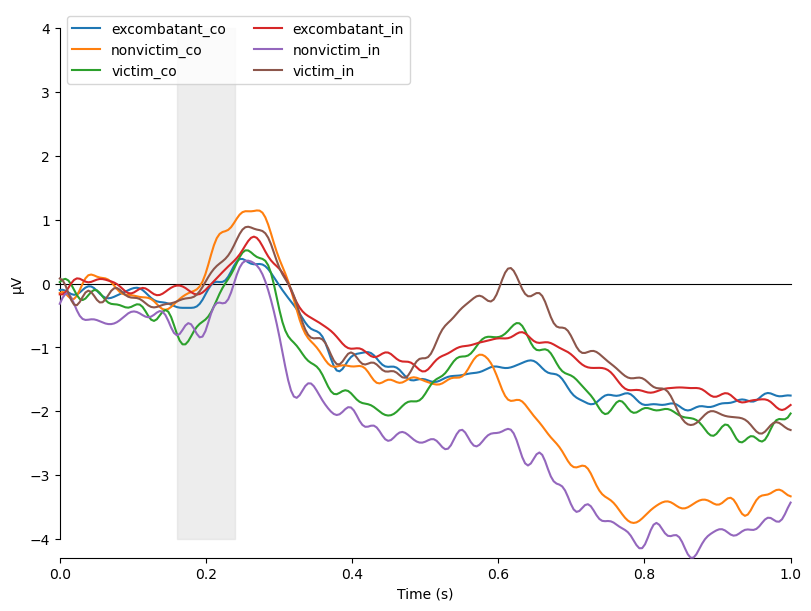

In [38]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='P2',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='type',
    tmin=0.0,
    tmax=1.0,
    conditions=['co','in'],
    ci=False
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

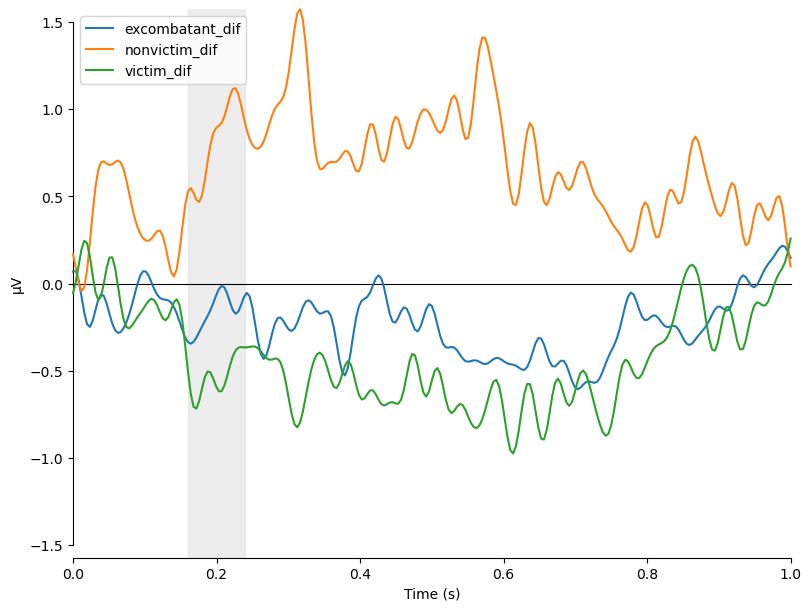

In [39]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='P2',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='type',
    tmin=0.0,
    tmax=1.0,
    conditions=['dif'],
    ci=False
    )

In [40]:
dv = 'dif_co_in_1'
between = 'type'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
                sum_sq    df         F    PR(>F)
C(type)      20.887323   2.0  8.376537  0.000536
C(gender)     6.679120   1.0  5.357115  0.023494
age           0.905832   1.0  0.726540  0.396833
scholarship   1.616898   1.0  1.296864  0.258562
Residual     89.767837  72.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
          type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0  excombatant                 -0.0916               0.1911          -0.4725   
1    nonvictim                  0.9965               0.3229           0.3528   
2       victim                 -0.8913               0.2924          -1.4743   

   IC_95%_Superior  
0           0.2892  
1           1.6401  
2          -0.3084  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
        Efecto  Eta_Squared_Parcial (η²p)
0      C(type)      

In [41]:
posthoc_contrasts_bonferroni(
    data=data_subjects_erps,
    dv=dv,
    between=between,
    ancova_model=ancova_model
)

--- Pruebas Post-Hoc (Bonferroni) en Medias Ajustadas ---
                 Comparación  Diferencia_Media_Ajustada  Estadístico_t  \
0  nonvictim vs. excombatant                     1.0881         2.9621   
1     victim vs. excombatant                    -0.7997        -2.0837   
2       victim vs. nonvictim                     1.8878         4.0374   

   p_valor_sin_ajustar  p_valor_Bonferroni  Significativo (alpha=0.05)  
0               0.0041              0.0124                        True  
1               0.0407              0.1222                       False  
2               0.0001              0.0004                        True  


**Conclusiones**: Hay diferencias significativas entre no-víctimas y excombatientes, y entre no-víctimas y víctimas, ya ajustando por las covariables. En no-víctimas las amplitudes promedio de los ensayos del bloque congruente tienden a ser más grandes (positivas) que las del incongruente. En excombatientes y víctimas sucede lo contrario, siendo más fuerte la diferncia con respecto a las víctimas.

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

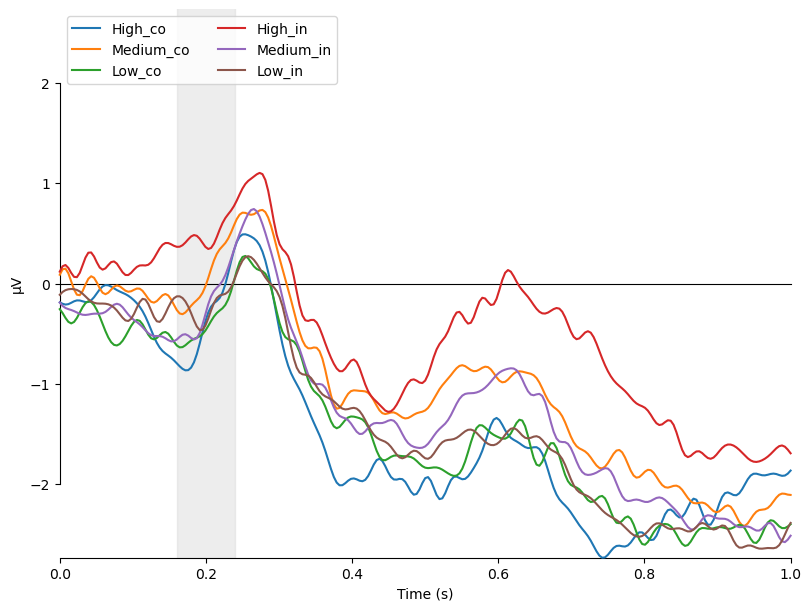

In [42]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='P2',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='IAT_level',
    tmin=0.0,
    tmax=1.0,
    conditions=['co','in'],
    ci=False
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

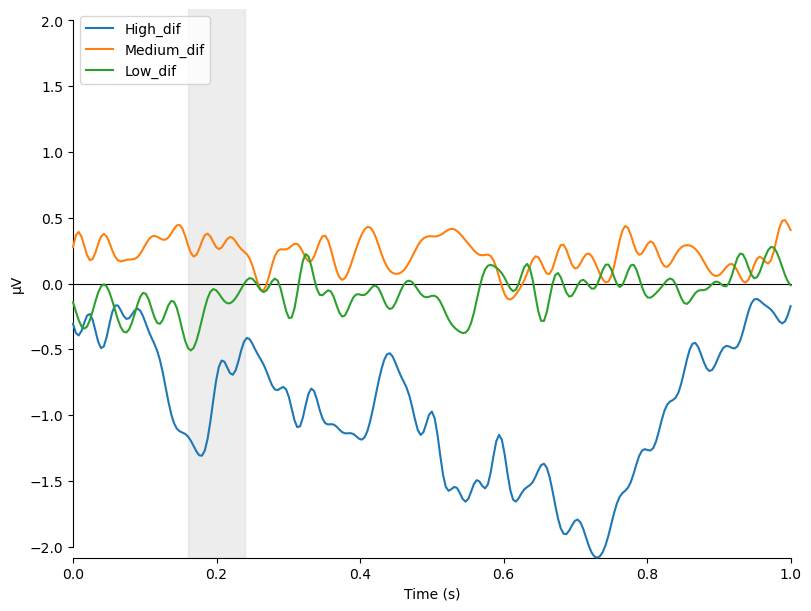

In [43]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='P2',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='IAT_level',
    tmin=0.0,
    tmax=1.0,
    conditions=['dif'],
    ci=False
    )

In [44]:
dv = 'dif_co_in_1'
between = 'IAT_level'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
                 sum_sq    df         F    PR(>F)
C(IAT_level)  16.721964   2.0  6.415327  0.002747
C(gender)      0.756641   1.0  0.580566  0.448614
age            3.669071   1.0  2.815254  0.097769
scholarship    1.054723   1.0  0.809282  0.371374
Residual      92.533046  71.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
     type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0    High                 -0.9820               0.2727          -1.5257   
1  Medium                  0.1893               0.1926          -0.1947   
2     Low                 -0.0340               0.2621          -0.5567   

   IC_95%_Superior  
0          -0.4383  
1           0.5733  
2           0.4887  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
         Efecto  Eta_Squared_Parcial (η²p)
0  C(IAT_level)                  

In [45]:
posthoc_contrasts_bonferroni(
    data=data_subjects_erps,
    dv=dv,
    between=between,
    ancova_model=ancova_model
)

--- Pruebas Post-Hoc (Bonferroni) en Medias Ajustadas ---
       Comparación  Diferencia_Media_Ajustada  Estadístico_t  \
0  Medium vs. High                     1.1713         3.5422   
1     Low vs. High                     0.9480         2.4494   
2   Low vs. Medium                     0.2233         0.6619   

   p_valor_sin_ajustar  p_valor_Bonferroni  Significativo (alpha=0.05)  
0               0.0007              0.0021                        True  
1               0.0168              0.0503                       False  
2               0.5102              1.0000                       False  


In [46]:
anova = anova_mixto(
    data=data_subjects_erps, 
    within=['mean_co_1', 'mean_in_1'], 
    between='IAT_level'
    )
anova

(        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
 0    IAT_level  3.435881    2   74  1.717940  0.754988  0.473602  0.019997   
 1    condition  0.846800    1   74  0.846800  1.288090  0.260063  0.017109   
 2  Interaction  9.091336    2   74  4.545668  6.914531  0.001766  0.157454   
 
    eps  
 0  NaN  
 1  1.0  
 2  NaN  ,
                 Contrast  condition          A          B Paired Parametric  \
 0              condition          -  mean_co_1  mean_in_1   True       True   
 1              IAT_level          -       High        Low  False       True   
 2              IAT_level          -       High     Medium  False       True   
 3              IAT_level          -        Low     Medium  False       True   
 4  condition * IAT_level  mean_co_1       High        Low  False       True   
 5  condition * IAT_level  mean_co_1       High     Medium  False       True   
 6  condition * IAT_level  mean_co_1        Low     Medium  False       True   
 

**Conclusiones**: Hay diferencias significativas entre sujetos con prejuicio hacia víctimas (level High) y sujetos sin prejucio marcado hacia ninguno de los 2 bandos (level Medium), ya ajustando por las covariables. Las amplitudes medias de los ERPs del bloque congruente de los sujetos con prejuicio hacia las víctimas tienden a ser menores a las del bloque incongruente. En los otros dos grupos las amplitudes en los 2 bloques tienden a ser similares.

### P3a

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

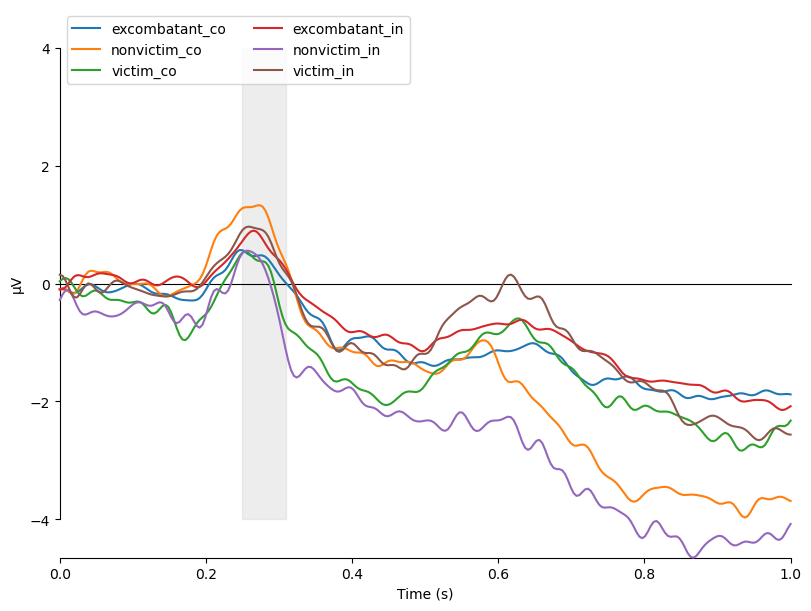

In [47]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='P3a',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='type',
    tmin=0.0,
    tmax=1.0,
    conditions=['co','in'],
    ci=False
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

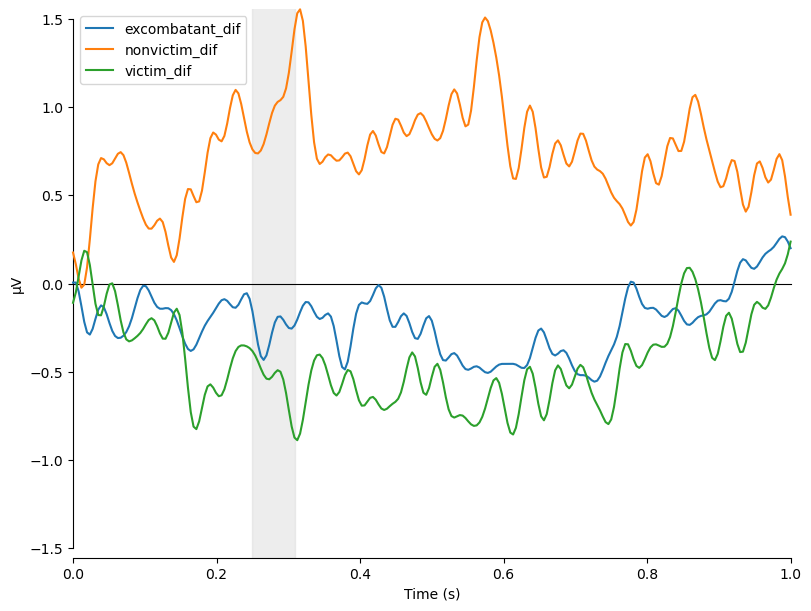

In [48]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='P3a',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='type',
    tmin=0.0,
    tmax=1.0,
    conditions=['dif'],
    ci=False
    )

In [49]:
dv = 'dif_co_in_2'
between = 'type'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
                 sum_sq    df         F    PR(>F)
C(type)       22.014497   2.0  7.762698  0.000885
C(gender)      2.376995   1.0  1.676340  0.199548
age            0.632109   1.0  0.445785  0.506478
scholarship    0.589166   1.0  0.415500  0.521239
Residual     102.093612  72.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
          type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0  excombatant                 -0.2159               0.2038          -0.6221   
1    nonvictim                  1.0964               0.3443           0.4100   
2       victim                 -0.7338               0.3119          -1.3554   

   IC_95%_Superior  
0           0.1902  
1           1.7828  
2          -0.1121  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
        Efecto  Eta_Squared_Parcial (η²p)
0      C(type)

In [50]:
posthoc_contrasts_bonferroni(
    data=data_subjects_erps,
    dv=dv,
    between=between,
    ancova_model=ancova_model
)

--- Pruebas Post-Hoc (Bonferroni) en Medias Ajustadas ---
                 Comparación  Diferencia_Media_Ajustada  Estadístico_t  \
0  nonvictim vs. excombatant                     1.3124         3.3500   
1     victim vs. excombatant                    -0.5178        -1.2651   
2       victim vs. nonvictim                     1.8302         3.6703   

   p_valor_sin_ajustar  p_valor_Bonferroni  Significativo (alpha=0.05)  
0               0.0013              0.0039                        True  
1               0.2099              0.6297                       False  
2               0.0005              0.0014                        True  


**Conclusiones**: Hay diferencias significativas entre no-víctimas y excombatientes, y entre no-víctimas y víctimas, ya ajustando por las covariables. En no-víctimas las amplitudes promedio de los ensayos del bloque congruente tienden a ser más grandes (positivas) que las del incongruente. En excombatientes y víctimas sucede lo contrario, siendo más fuerte la diferncia con respecto a las víctimas.

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

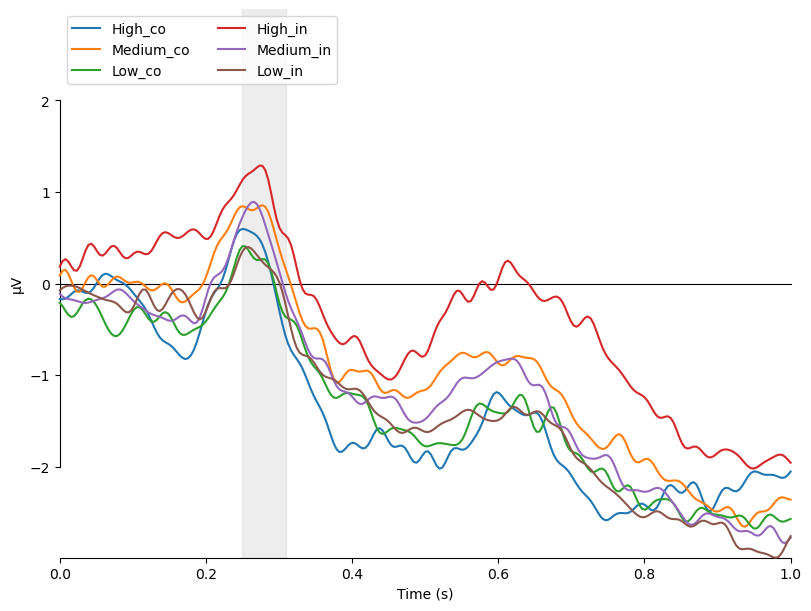

In [51]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='P3a',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='IAT_level',
    tmin=0.0,
    tmax=1.0,
    conditions=['co','in'],
    ci=False
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

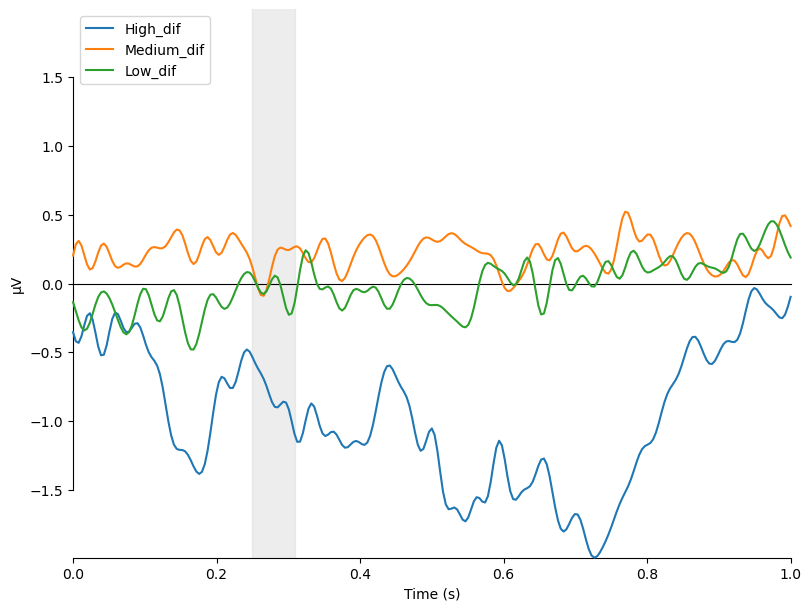

In [52]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='P3a',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='IAT_level',
    tmin=0.0,
    tmax=1.0,
    conditions=['dif'],
    ci=False
    )

In [53]:
dv = 'dif_co_in_2'
between = 'IAT_level'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
                  sum_sq    df         F    PR(>F)
C(IAT_level)    9.706657   2.0  3.024107  0.054903
C(gender)       0.008983   1.0  0.005597  0.940574
age             3.285172   1.0  2.046990  0.156894
scholarship     0.044777   1.0  0.027901  0.867817
Residual      113.946456  71.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
     type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0    High                 -0.7927               0.3026          -1.3960   
1  Medium                  0.0785               0.2137          -0.3477   
2     Low                  0.0130               0.2909          -0.5670   

   IC_95%_Superior  
0          -0.1894  
1           0.5046  
2           0.5931  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
         Efecto  Eta_Squared_Parcial (η²p)
0  C(IAT_level)            

**Conclusiones**: No hay diferencias significativas entre niveles de prejuicio, ya ajustando por las covariables.

### N400

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

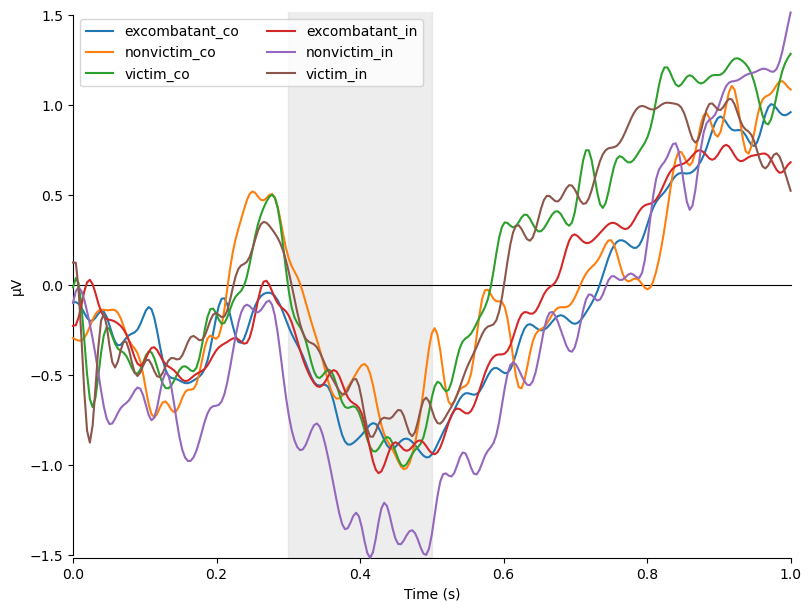

In [54]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='N400',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='type',
    tmin=0.0,
    tmax=1.0,
    conditions=['co','in'],
    ci=False
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

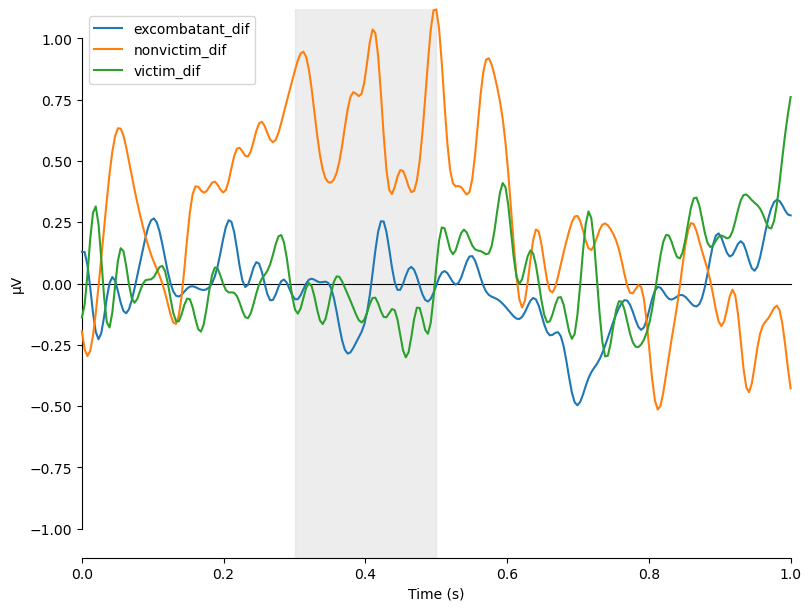

In [55]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='N400',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='type',
    tmin=0.0,
    tmax=1.0,
    conditions=['dif'],
    ci=False
    )

In [56]:
dv = 'dif_co_in_3'
between = 'type'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
                 sum_sq    df         F    PR(>F)
C(type)       19.356646   2.0  5.996740  0.003901
C(gender)      2.174640   1.0  1.347419  0.249564
age            1.411954   1.0  0.874854  0.352741
scholarship    1.531424   1.0  0.948878  0.333266
Residual     116.203009  72.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
          type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0  excombatant                 -0.1658               0.2174          -0.5991   
1    nonvictim                  1.0096               0.3674           0.2773   
2       victim                 -0.7485               0.3327          -1.4117   

   IC_95%_Superior  
0           0.2676  
1           1.7419  
2          -0.0852  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
        Efecto  Eta_Squared_Parcial (η²p)
0      C(type)

In [57]:
posthoc_contrasts_bonferroni(
    data=data_subjects_erps,
    dv=dv,
    between=between,
    ancova_model=ancova_model
)

--- Pruebas Post-Hoc (Bonferroni) en Medias Ajustadas ---
                 Comparación  Diferencia_Media_Ajustada  Estadístico_t  \
0  nonvictim vs. excombatant                     1.1754         2.8123   
1     victim vs. excombatant                    -0.5827        -1.3345   
2       victim vs. nonvictim                     1.7581         3.3048   

   p_valor_sin_ajustar  p_valor_Bonferroni  Significativo (alpha=0.05)  
0               0.0063              0.0190                        True  
1               0.1863              0.5588                       False  
2               0.0015              0.0045                        True  


**Conclusiones**: Hay diferencias significativas entre no-víctimas y excombatientes, y entre no-víctimas y víctimas, ya ajustando por las covariables. En no-víctimas las amplitudes promedio de los ensayos del bloque incongruente tienden a ser más grandes (negativas) que las del congruente. En excombatientes y víctimas sucede lo contrario, siendo más fuerte la diferencia con respecto a las víctimas.

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

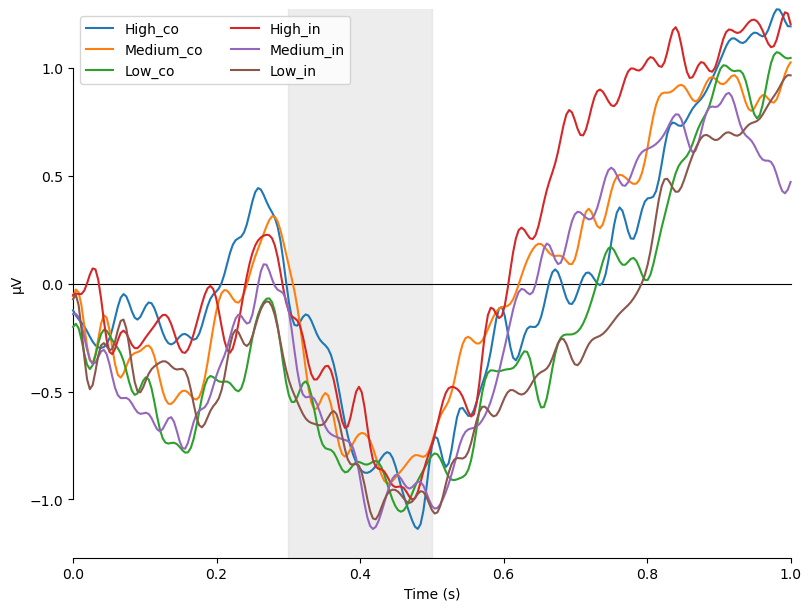

In [58]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='N400',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='IAT_level',
    tmin=0.0,
    tmax=1.0,
    conditions=['co','in'],
    ci=False
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

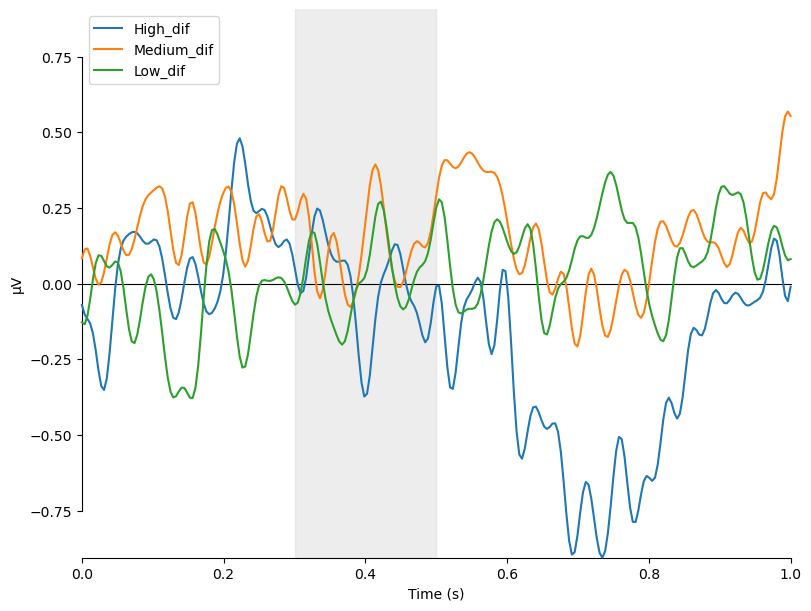

In [59]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='N400',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='IAT_level',
    tmin=0.0,
    tmax=1.0,
    conditions=['dif'],
    ci=False
    )

In [60]:
dv = 'dif_co_in_3'
between = 'IAT_level'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
                  sum_sq    df         F    PR(>F)
C(IAT_level)   16.801158   2.0  5.122515  0.008354
C(gender)       0.020261   1.0  0.012355  0.911810
age             4.320147   1.0  2.634344  0.109007
scholarship     0.878915   1.0  0.535946  0.466527
Residual      116.435214  71.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
     type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0    High                 -1.0016               0.3059          -1.6115   
1  Medium                  0.1461               0.2160          -0.2847   
2     Low                  0.0539               0.2941          -0.5325   

   IC_95%_Superior  
0          -0.3917  
1           0.5768  
2           0.6402  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
         Efecto  Eta_Squared_Parcial (η²p)
0  C(IAT_level)            

In [61]:
posthoc_contrasts_bonferroni(
    data=data_subjects_erps,
    dv=dv,
    between=between,
    ancova_model=ancova_model
)

--- Pruebas Post-Hoc (Bonferroni) en Medias Ajustadas ---
       Comparación  Diferencia_Media_Ajustada  Estadístico_t  \
0  Medium vs. High                     1.1477         3.0941   
1     Low vs. High                     1.0555         2.4312   
2   Low vs. Medium                     0.0922         0.2436   

   p_valor_sin_ajustar  p_valor_Bonferroni  Significativo (alpha=0.05)  
0               0.0028              0.0085                        True  
1               0.0176              0.0527                       False  
2               0.8082              1.0000                       False  


**Conclusiones**: Hay diferencias significativas entre sujetos con prejuicio hacia víctimas (level High) y sujetos sin prejucio marcado hacia ninguno de los 2 bandos (level Medium), ya ajustando por las covariables. Las amplitudes medias de los ERPs del bloque congruente de los sujetos con prejuicio hacia las víctimas tienden a ser mayores (más negativas) a las del bloque incongruente. En los otros dos grupos tienden a ser semejantes.

### N450

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

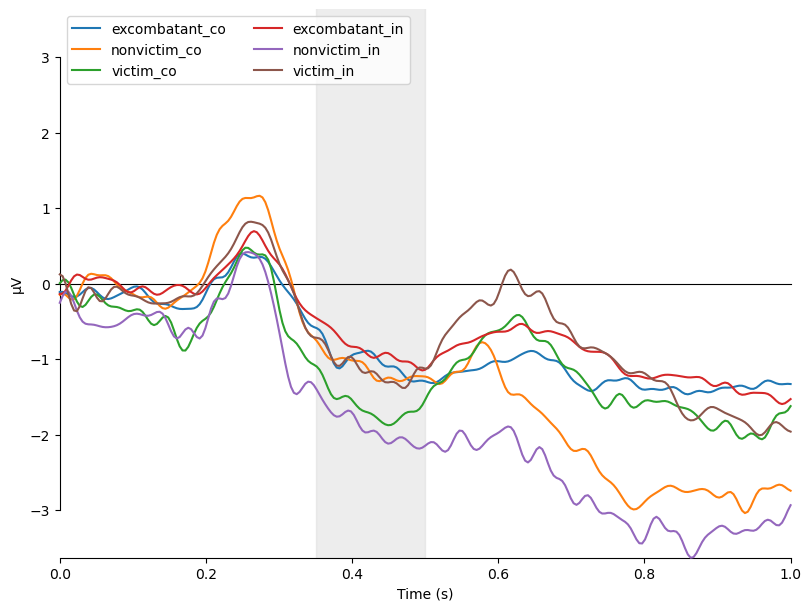

In [62]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='N450',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='type',
    tmin=0.0,
    tmax=1.0,
    conditions=['co','in'],
    ci=False
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

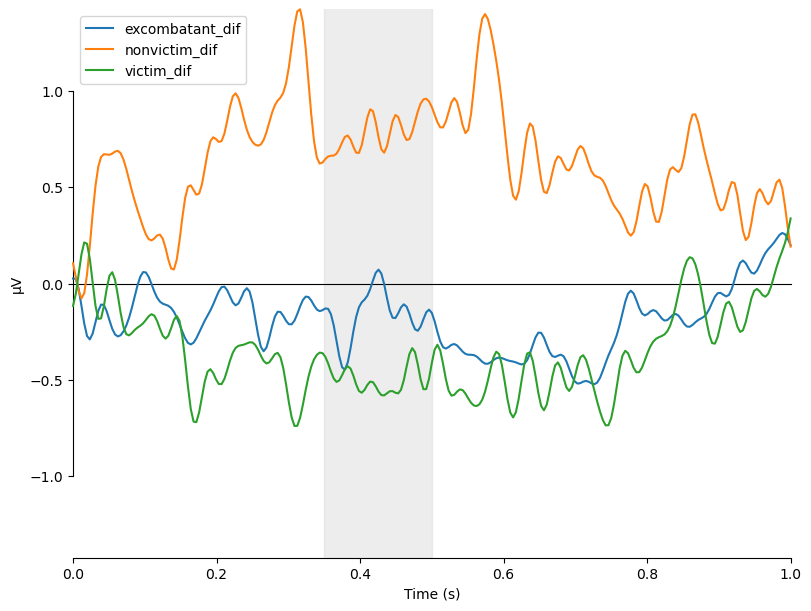

In [63]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='N450',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='type',
    tmin=0.0,
    tmax=1.0,
    conditions=['dif'],
    ci=False
    )

In [64]:
dv = 'dif_co_in_5'
between = 'type'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
                 sum_sq    df         F    PR(>F)
C(type)       17.602456   2.0  4.883680  0.010259
C(gender)      2.698197   1.0  1.497192  0.225093
age            1.395328   1.0  0.774248  0.381833
scholarship    1.367578   1.0  0.758850  0.386584
Residual     129.756329  72.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
          type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0  excombatant                 -0.1621               0.2297          -0.6200   
1    nonvictim                  0.9309               0.3882           0.1570   
2       victim                 -0.7625               0.3516          -1.4633   

   IC_95%_Superior  
0           0.2958  
1           1.7047  
2          -0.0616  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
        Efecto  Eta_Squared_Parcial (η²p)
0      C(type)

In [65]:
posthoc_contrasts_bonferroni(
    data=data_subjects_erps,
    dv=dv,
    between=between,
    ancova_model=ancova_model
)

--- Pruebas Post-Hoc (Bonferroni) en Medias Ajustadas ---
                 Comparación  Diferencia_Media_Ajustada  Estadístico_t  \
0  nonvictim vs. excombatant                     1.0929         2.4747   
1     victim vs. excombatant                    -0.6004        -1.3012   
2       victim vs. nonvictim                     1.6933         3.0123   

   p_valor_sin_ajustar  p_valor_Bonferroni  Significativo (alpha=0.05)  
0               0.0157              0.0471                        True  
1               0.1973              0.5920                       False  
2               0.0036              0.0107                        True  


**Conclusiones**: Hay diferencias significativas entre no-víctimas y excombatientes, y entre no-víctimas y víctimas, ya ajustando por las covariables. En no-víctimas las amplitudes promedio de los ensayos del bloque incongruente tienden a ser más grandes (negativas) que las del congruente. En víctimas sucede lo contrario, y en excombatientes las amplitudes de los 2 bloques tienden a ser similares.

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

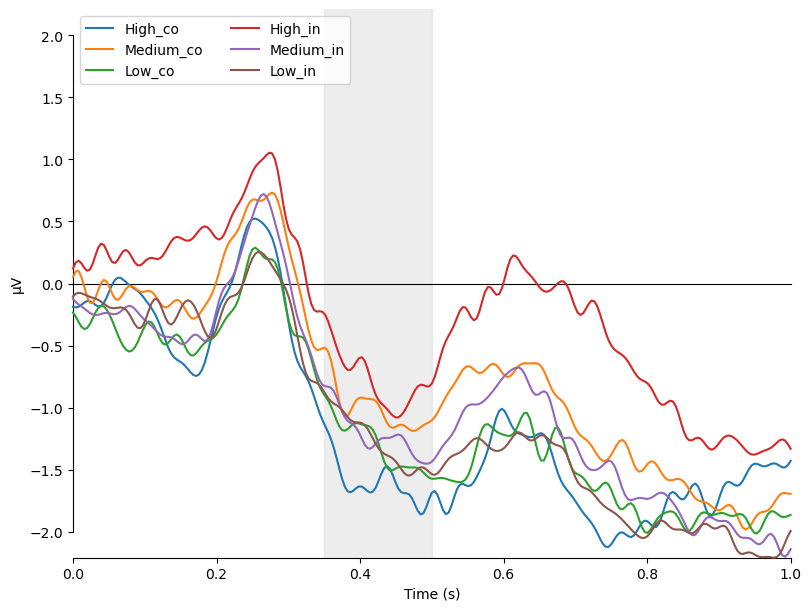

In [66]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='N450',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='IAT_level',
    tmin=0.0,
    tmax=1.0,
    conditions=['co','in'],
    ci=False
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

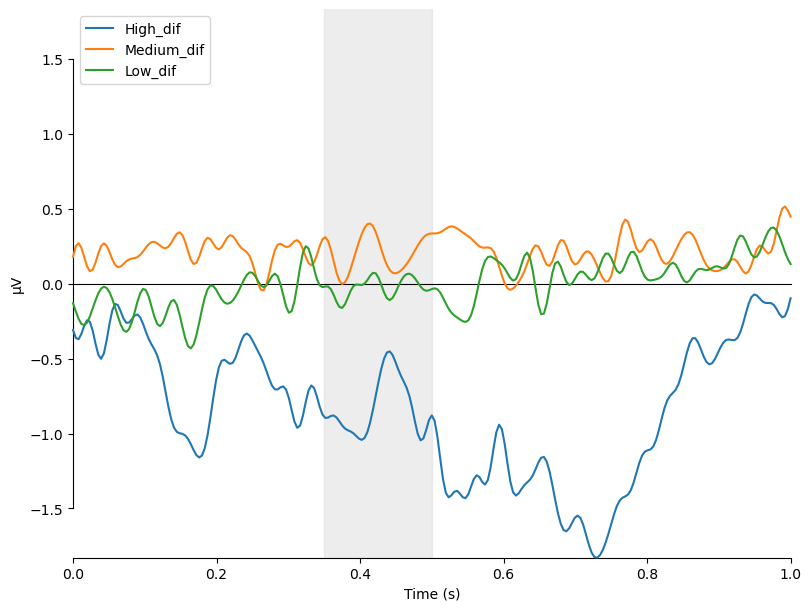

In [67]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='N450',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='IAT_level',
    tmin=0.0,
    tmax=1.0,
    conditions=['dif'],
    ci=False
    )

In [68]:
dv = 'dif_co_in_5'
between = 'IAT_level'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
                  sum_sq    df         F    PR(>F)
C(IAT_level)   16.460040   2.0  4.503381  0.014410
C(gender)       0.098219   1.0  0.053744  0.817338
age             4.280651   1.0  2.342327  0.130345
scholarship     0.858823   1.0  0.469939  0.495248
Residual      129.753954  71.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
     type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0    High                 -1.0027               0.3229          -1.6465   
1  Medium                  0.1343               0.2281          -0.3205   
2     Low                  0.0390               0.3104          -0.5800   

   IC_95%_Superior  
0          -0.3589  
1           0.5890  
2           0.6580  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
         Efecto  Eta_Squared_Parcial (η²p)
0  C(IAT_level)            

In [69]:
posthoc_contrasts_bonferroni(
    data=data_subjects_erps,
    dv=dv,
    between=between,
    ancova_model=ancova_model
)

--- Pruebas Post-Hoc (Bonferroni) en Medias Ajustadas ---
       Comparación  Diferencia_Media_Ajustada  Estadístico_t  \
0  Medium vs. High                     1.1370         2.9036   
1     Low vs. High                     1.0417         2.2730   
2   Low vs. Medium                     0.0953         0.2384   

   p_valor_sin_ajustar  p_valor_Bonferroni  Significativo (alpha=0.05)  
0               0.0049              0.0147                        True  
1               0.0261              0.0782                       False  
2               0.8122              1.0000                       False  


**Conclusiones**: Hay diferencias significativas entre sujetos con prejuicio hacia víctimas (level High) y sujetos sin prejucio marcado hacia ninguno de los 2 bandos (level Medium), ya ajustando por las covariables. Las amplitudes medias de los ERPs del bloque congruente de los sujetos con prejuicio hacia las víctimas tienden a ser mayores (más negativas) a las del bloque incongruente. En los otros dos grupos tienden a ser similares.

### LPP

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

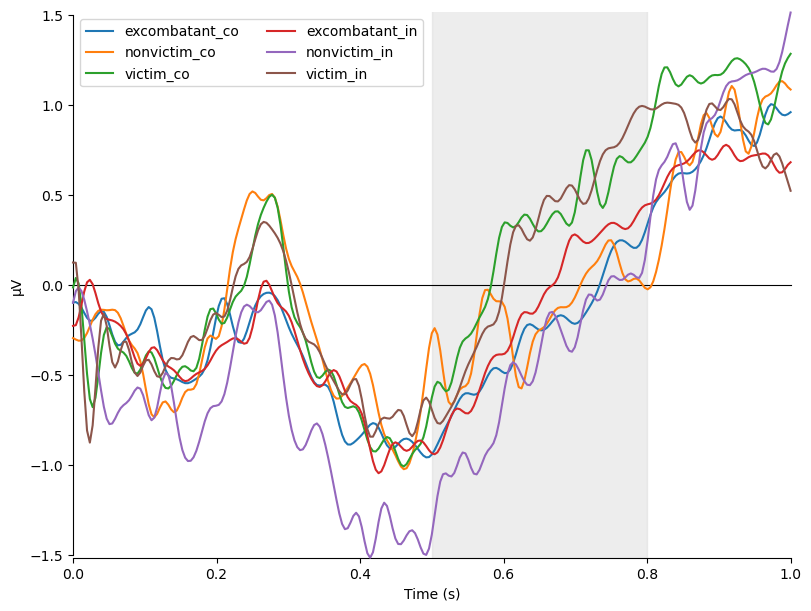

In [70]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='LPP',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='type',
    tmin=0.0,
    tmax=1.0,
    conditions=['co','in'],
    ci=False
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

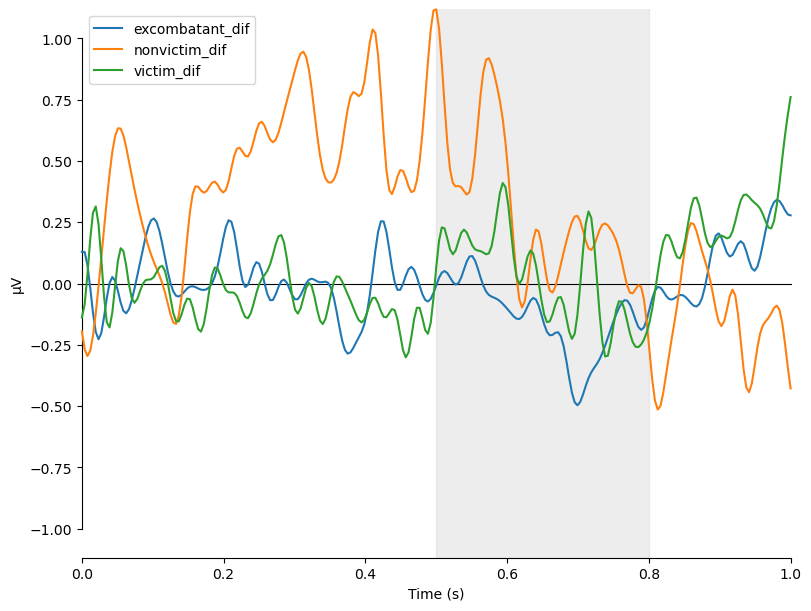

In [71]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='LPP',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='type',
    tmin=0.0,
    tmax=1.0,
    conditions=['dif'],
    ci=False
    )

In [72]:
dv = 'dif_co_in_4'
between = 'type'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
                 sum_sq    df         F    PR(>F)
C(type)       17.654361   2.0  3.767546  0.027788
C(gender)      0.489441   1.0  0.208899  0.649008
age            0.784585   1.0  0.334870  0.564611
scholarship    0.827593   1.0  0.353226  0.554155
Residual     168.692578  72.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
          type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0  excombatant                 -0.3788               0.2619          -0.9010   
1    nonvictim                  0.8794               0.4426          -0.0029   
2       victim                 -0.6649               0.4009          -1.4640   

   IC_95%_Superior  
0           0.1433  
1           1.7617  
2           0.1343  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
        Efecto  Eta_Squared_Parcial (η²p)
0      C(type)

In [73]:
posthoc_contrasts_bonferroni(
    data=data_subjects_erps,
    dv=dv,
    between=between,
    ancova_model=ancova_model
)

--- Pruebas Post-Hoc (Bonferroni) en Medias Ajustadas ---
                 Comparación  Diferencia_Media_Ajustada  Estadístico_t  \
0  nonvictim vs. excombatant                     1.2582         2.4986   
1     victim vs. excombatant                    -0.2860        -0.5437   
2       victim vs. nonvictim                     1.5442         2.4093   

   p_valor_sin_ajustar  p_valor_Bonferroni  Significativo (alpha=0.05)  
0               0.0148              0.0443                        True  
1               0.5884              1.0000                       False  
2               0.0185              0.0556                       False  


**Conclusiones**: Hay diferencias significativas entre no-víctimas y excombatientes, ya ajustando por las covariables. En no-víctimas las amplitudes promedio de los ensayos del bloque congruente tienden a ser más grandes (positivas) que las del incongruente. En víctimas y excombatientes tiende a suceder lo contrario.

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

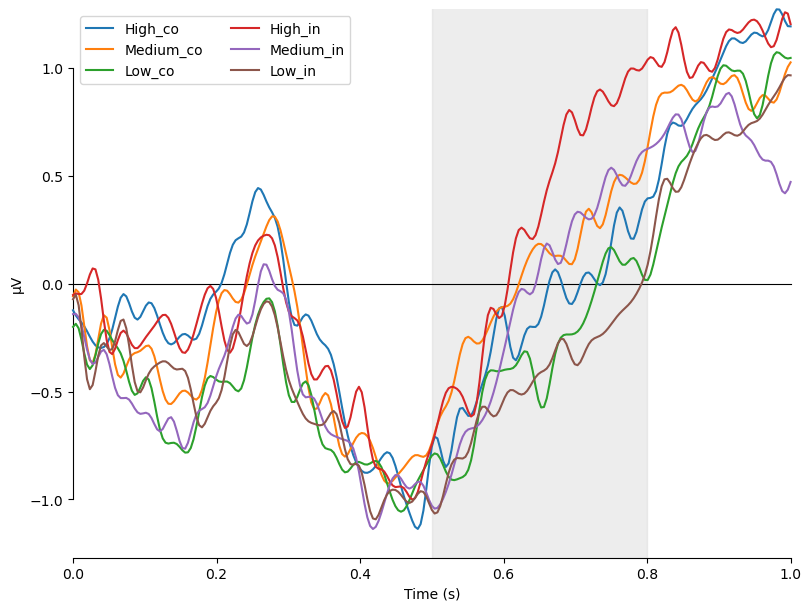

In [74]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='LPP',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='IAT_level',
    tmin=0.0,
    tmax=1.0,
    conditions=['co','in'],
    ci=False
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode

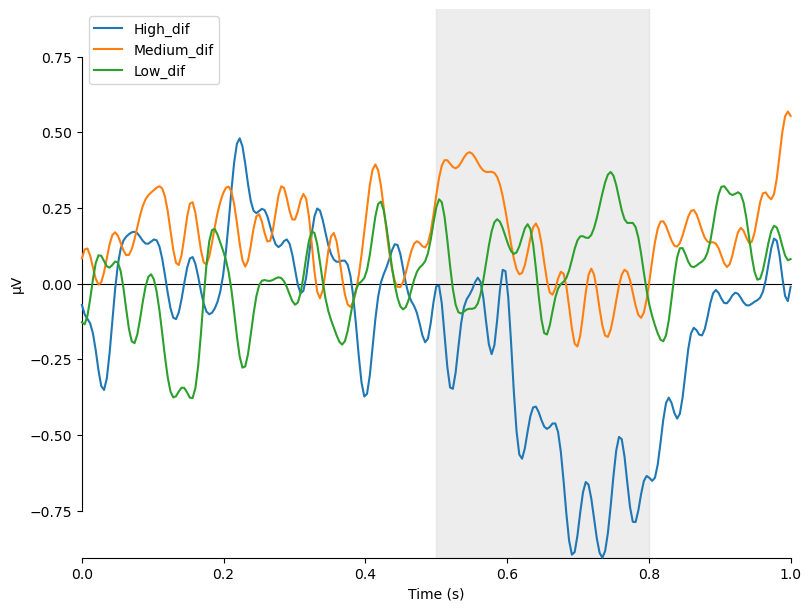

In [75]:
fig = erp_factor(
    df_clusters=df_clusters,
    componente='LPP',
    df_sujetos=preserved,
    evocados_co=evocados_co,
    evocados_in=evocados_in,
    factor='IAT_level',
    tmin=0.0,
    tmax=1.0,
    conditions=['dif'],
    ci=False
    )

In [76]:
dv = 'dif_co_in_4'
between = 'IAT_level'

ancova_model = test_ancova_full(
    data=data_subjects_erps, 
    dv=dv, 
    between=between
)

verify_ancova_assumptions(
    data=data_subjects_erps,
    dv=dv,
    between=between
)

--- Tabla ANCOVA del Modelo Final ---
                  sum_sq    df         F    PR(>F)
C(IAT_level)   38.827970   2.0  9.360747  0.000247
C(gender)       0.001144   1.0  0.000551  0.981330
age             2.169188   1.0  1.045907  0.309924
scholarship     0.320110   1.0  0.154346  0.695593
Residual      147.252454  71.0       NaN       NaN
------------------------------------
--- Medias Ajustadas, Error Estándar e Intervalos de Confianza (95%) ---
     type  Media_Ajustada (M_adj)  Error_Estandar (EE)  IC_95%_Inferior  \
0    High                 -1.5442               0.3440          -2.2300   
1  Medium                  0.1983               0.2430          -0.2861   
2     Low                  0.0668               0.3307          -0.5926   

   IC_95%_Superior  
0          -0.8583  
1           0.6828  
2           0.7262  
------------------------------------
--- Tamaños del Efecto: Partial Eta-Squared (η²p) ---
         Efecto  Eta_Squared_Parcial (η²p)
0  C(IAT_level)            

In [77]:
posthoc_contrasts_bonferroni(
    data=data_subjects_erps,
    dv=dv,
    between=between,
    ancova_model=ancova_model
)

--- Pruebas Post-Hoc (Bonferroni) en Medias Ajustadas ---
       Comparación  Diferencia_Media_Ajustada  Estadístico_t  \
0  Medium vs. High                     1.7425         4.1774   
1     Low vs. High                     1.6110         3.2996   
2   Low vs. Medium                     0.1315         0.3091   

   p_valor_sin_ajustar  p_valor_Bonferroni  Significativo (alpha=0.05)  
0               0.0001              0.0002                        True  
1               0.0015              0.0045                        True  
2               0.7582              1.0000                       False  


**Conclusiones**: Hay diferencias significativas entre sujetos con prejuicio hacia víctimas (level High) y sujetos sin prejucio marcado hacia ninguno de los 2 bandos (level Medium), y entre sujetos con prejuicio hacia víctimas (level High) y sujetos con prejucio hacia combatientes, ya ajustando por las covariables. Las amplitudes medias de los ERPs del bloque incongruente de los sujetos con prejuicio hacia las víctimas tienden a ser mayores (más positivas) a las del bloque congruente. En los otros dos grupos tienden a ser similares.